In [1]:
!nvcc --version
!nvidia-smi

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0
Mon Apr 27 05:35:59 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8       

Лабораторная работа 8.1 – сложение векторов

In [2]:
%%writefile 01_vec_add.cu
#include <cuda.h>
#include <cuda_runtime.h>

__global__ void VecAddKernel(const float *a, const float *b, float *c) {
    int i = threadIdx.x + blockIdx.x * blockDim.x;
    c[i] = a[i] + b[i];
}

extern "C" void vec_add_cuda(const float *a, const float *b, float *c, int n) {
    size_t size = n * sizeof(float);
    float *d_a = 0, *d_b = 0, *d_c = 0;

    cudaMalloc(&d_a, size);
    cudaMalloc(&d_b, size);
    cudaMalloc(&d_c, size);

    cudaMemcpy(d_a, a, size, cudaMemcpyHostToDevice);
    cudaMemcpy(d_b, b, size, cudaMemcpyHostToDevice);

    dim3 threads(512);
    dim3 blocks((n + threads.x - 1) / threads.x);

    VecAddKernel<<<blocks, threads>>>(d_a, d_b, d_c);

    cudaMemcpy(c, d_c, size, cudaMemcpyDeviceToHost);

    cudaFree(d_a);
    cudaFree(d_b);
    cudaFree(d_c);
}

Writing 01_vec_add.cu


In [3]:
%%writefile 01_main.cpp
#include <iostream>
#include <cstdlib>
#include <ctime>
#include <cmath>

extern "C" void vec_add_cuda(const float *a, const float *b, float *c, int n);

void vec_add_cpu(const float *a, const float *b, float *c, int n) {
    for (int i = 0; i < n; ++i) c[i] = a[i] + b[i];
}

int main() {
    const int N = 1024;
    float a[N], b[N], c_gpu[N], c_cpu[N];

    std::srand(std::time(nullptr));
    for (int i = 0; i < N; ++i) {
        a[i] = static_cast<float>(std::rand()) / RAND_MAX;
        b[i] = static_cast<float>(std::rand()) / RAND_MAX;
    }

    vec_add_cuda(a, b, c_gpu, N);
    vec_add_cpu(a, b, c_cpu, N);

    bool ok = true;
    for (int i = 0; i < N; ++i) {
        if (std::fabs(c_gpu[i] - c_cpu[i]) > 1e-5) {
            ok = false;
            std::cout << "Mismatch at " << i << std::endl;
            break;
        }
    }
    if (ok) std::cout << "GPU and CPU results match!\n";

    std::cout << "First 10 sums: ";
    for (int i = 0; i < 10; ++i)
        std::cout << c_gpu[i] << " ";
    std::cout << std::endl;

    return 0;
}

Writing 01_main.cpp


In [4]:
%%bash
nvcc -o lab8_1 01_vec_add.cu 01_main.cpp
./lab8_1

GPU and CPU results match!
First 10 sums: 1.15704 1.01273 1.32739 0.94704 0.488558 0.560952 0.731386 0.598442 1.37567 0.59472 


nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).


Лабораторная работа 8.2 – параметры GPU

In [5]:
%%writefile 02_gpu_info.cu
#include <cuda.h>
#include <cuda_runtime.h>
#include <iostream>
#include <iomanip>

int main() {
    int deviceCount;
    cudaGetDeviceCount(&deviceCount);
    std::cout << "CUDA device count: " << deviceCount << "\n\n";

    for (int i = 0; i < deviceCount; ++i) {
        cudaDeviceProp prop;
        cudaGetDeviceProperties(&prop, i);

        std::cout << "Device " << i << ": " << prop.name << "\n";
        std::cout << "  Compute capability:            " << prop.major << "." << prop.minor << "\n";
        std::cout << "  Total global memory (GB):      " << std::fixed << std::setprecision(2)
                  << prop.totalGlobalMem / (1024.0*1024.0*1024.0) << "\n";
        std::cout << "  Constant memory (KB):          " << prop.totalConstMem / 1024.0 << "\n";
        std::cout << "  Shared memory per block (KB):  " << prop.sharedMemPerBlock / 1024.0 << "\n";
        std::cout << "  Registers per block:           " << prop.regsPerBlock << "\n";
        std::cout << "  Warp size:                     " << prop.warpSize << "\n";
        std::cout << "  Max threads per block:         " << prop.maxThreadsPerBlock << "\n";
        std::cout << "  Number of multiprocessors:     " << prop.multiProcessorCount << "\n";
        std::cout << "  Core clock rate (MHz):         " << prop.clockRate / 1000.0 << "\n";
        std::cout << "  Memory clock rate (MHz):       " << prop.memoryClockRate / 1000.0 << "\n";
        std::cout << "  L2 cache size (KB):            " << prop.l2CacheSize / 1024.0 << "\n";
        std::cout << "  Memory bus width (bit):        " << prop.memoryBusWidth << "\n";
        std::cout << "  Max block dim:                 " << prop.maxThreadsDim[0] << " x "
                  << prop.maxThreadsDim[1] << " x " << prop.maxThreadsDim[2] << "\n";
        std::cout << "  Max grid dim:                  " << prop.maxGridSize[0] << " x "
                  << prop.maxGridSize[1] << " x " << prop.maxGridSize[2] << "\n\n";
    }
    return 0;
}

Writing 02_gpu_info.cu


In [6]:
%%bash
nvcc -o lab8_2 02_gpu_info.cu
./lab8_2

CUDA device count: 1

Device 0: Tesla T4
  Compute capability:            7.5
  Total global memory (GB):      14.56
  Constant memory (KB):          64.00
  Shared memory per block (KB):  48.00
  Registers per block:           65536
  Warp size:                     32
  Max threads per block:         1024
  Number of multiprocessors:     40
  Core clock rate (MHz):         1590.00
  Memory clock rate (MHz):       5001.00
  L2 cache size (KB):            4096.00
  Memory bus width (bit):        256
  Max block dim:                 1024 x 1024 x 64
  Max grid dim:                  2147483647 x 65535 x 65535



nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).


Лабораторная работа 8.3 – пропускная способность

In [7]:
%%writefile 03_bandwidth.cu
#include <cuda.h>
#include <cuda_runtime.h>
#include <iostream>
#include <cstring>
#include <chrono>

using namespace std::chrono;

void test_copy(const char* label, void* dst, void* src, size_t bytes, cudaMemcpyKind kind, bool sync=false) {
    auto start = high_resolution_clock::now();
    cudaError_t err = cudaMemcpy(dst, src, bytes, kind);
    if (err != cudaSuccess) {
        std::cerr << "cudaMemcpy failed: " << cudaGetErrorString(err) << "\n";
        return;
    }
    if (sync) cudaDeviceSynchronize();
    auto end = high_resolution_clock::now();
    double time_ms = duration<double, std::milli>(end - start).count();
    double bw_gb = (bytes / (1024.0*1024.0*1024.0)) / (time_ms / 1000.0);
    std::cout << label << " : " << time_ms << " ms, " << bw_gb << " GB/s\n";
}

int main() {
    const size_t N = 256 * 1024 * 1024; // 256 MB
    const size_t bytes = N * sizeof(float);

    float *h_a = (float*)malloc(bytes);
    float *h_b = (float*)malloc(bytes);
    float *h_a_pinned, *h_b_pinned;
    cudaMallocHost(&h_a_pinned, bytes);
    cudaMallocHost(&h_b_pinned, bytes);

    float *d_a, *d_b;
    cudaMalloc(&d_a, bytes);
    cudaMalloc(&d_b, bytes);

    memset(h_a, 0, bytes);
    memset(h_b, 0, bytes);
    memset(h_a_pinned, 0, bytes);
    memset(h_b_pinned, 0, bytes);

    test_copy("Host->Host (pageable)   ", h_b, h_a, bytes, cudaMemcpyHostToHost);
    test_copy("Host->Device (pageable) ", d_a, h_a, bytes, cudaMemcpyHostToDevice);
    test_copy("Host->Device (pinned)   ", d_a, h_a_pinned, bytes, cudaMemcpyHostToDevice);
    test_copy("Device->Host (pageable) ", h_b, d_a, bytes, cudaMemcpyDeviceToHost);
    test_copy("Device->Host (pinned)   ", h_b_pinned, d_a, bytes, cudaMemcpyDeviceToHost);
    test_copy("Device->Device          ", d_b, d_a, bytes, cudaMemcpyDeviceToDevice, true);

    free(h_a);
    free(h_b);
    cudaFreeHost(h_a_pinned);
    cudaFreeHost(h_b_pinned);
    cudaFree(d_a);
    cudaFree(d_b);

    return 0;
}

Writing 03_bandwidth.cu


In [8]:
%%bash
nvcc -o lab8_3 03_bandwidth.cu
./lab8_3

Host->Host (pageable)    : 234.385 ms, 4.26649 GB/s
Host->Device (pageable)  : 226.735 ms, 4.41043 GB/s
Host->Device (pinned)    : 86.8325 ms, 11.5164 GB/s
Device->Host (pageable)  : 252.458 ms, 3.96105 GB/s
Device->Host (pinned)    : 81.6224 ms, 12.2515 GB/s
Device->Device           : 8.93955 ms, 111.862 GB/s


nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).


Лабораторная работа 8.4 – умножение матриц

In [9]:
%%writefile 04_matmul.cu
#include <cuda.h>
#include <cuda_runtime.h>
#include <stdio.h>
#include <cmath>

__global__ void matmul_naive(const float *A, const float *B, float *C, int n) {
    int row = blockIdx.y * blockDim.y + threadIdx.y;
    int col = blockIdx.x * blockDim.x + threadIdx.x;
    if (row < n && col < n) {
        float sum = 0.0f;
        for (int k = 0; k < n; k++)
            sum += A[row * n + k] * B[k * n + col];
        C[row * n + col] = sum;
    }
}

__global__ void matmul_row_cache(const float *A, const float *B, float *C, int n) {
    extern __shared__ float sharedA[];
    int row = blockIdx.x;
    int col = threadIdx.x;
    if (col < n)
        sharedA[col] = A[row * n + col];
    __syncthreads();
    if (row < n && col < n) {
        float sum = 0.0f;
        for (int k = 0; k < n; k++)
            sum += sharedA[k] * B[k * n + col];
        C[row * n + col] = sum;
    }
}

__global__ void matmul_col_cache(const float *A, const float *B, float *C, int n) {
    extern __shared__ float sharedB[];
    int row = threadIdx.x;
    int col = blockIdx.x;
    if (row < n)
        sharedB[row] = B[row * n + col];
    __syncthreads();
    if (row < n && col < n) {
        float sum = 0.0f;
        for (int k = 0; k < n; k++)
            sum += A[row * n + k] * sharedB[k];
        C[row * n + col] = sum;
    }
}

// Блочное умножение (tiling) с заданным размером блока S
__global__ void matmul_tiled(const float *A, const float *B, float *C, int n, int S) {
    int bx = blockIdx.x, by = blockIdx.y;
    int tx = threadIdx.x, ty = threadIdx.y;
    int aBegin = n * S * by;
    int aEnd = aBegin + n - 1;
    int aStep = S;
    int bBegin = S * bx;
    int bStep = S * n;
    float sum = 0.0f;

    for (int a = aBegin, b = bBegin; a <= aEnd; a += aStep, b += bStep) {
        __shared__ float As[32][32]; // предполагаем S <= 32
        __shared__ float Bs[32][32];
        As[ty][tx] = A[a + n * ty + tx];
        Bs[ty][tx] = B[b + n * ty + tx];
        __syncthreads();
        for (int k = 0; k < S; k++)
            sum += As[ty][k] * Bs[k][tx];
        __syncthreads();
    }
    int row = by * S + ty;
    int col = bx * S + tx;
    if (row < n && col < n)
        C[row * n + col] = sum;
}

void run_naive(const float *hA, const float *hB, float *hC, int n) {
    size_t size = n * n * sizeof(float);
    float *dA, *dB, *dC;
    cudaMalloc(&dA, size); cudaMalloc(&dB, size); cudaMalloc(&dC, size);
    cudaMemcpy(dA, hA, size, cudaMemcpyHostToDevice);
    cudaMemcpy(dB, hB, size, cudaMemcpyHostToDevice);

    int blockSize = 16; // фиксированный, т.к. naive не использует shared memory
    dim3 threads(blockSize, blockSize);
    dim3 blocks((n + blockSize - 1)/blockSize, (n + blockSize - 1)/blockSize);
    matmul_naive<<<blocks, threads>>>(dA, dB, dC, n);
    cudaDeviceSynchronize();

    cudaMemcpy(hC, dC, size, cudaMemcpyDeviceToHost);
    cudaFree(dA); cudaFree(dB); cudaFree(dC);
}

void run_row_cache(const float *hA, const float *hB, float *hC, int n) {
    size_t size = n * n * sizeof(float);
    float *dA, *dB, *dC;
    cudaMalloc(&dA, size); cudaMalloc(&dB, size); cudaMalloc(&dC, size);
    cudaMemcpy(dA, hA, size, cudaMemcpyHostToDevice);
    cudaMemcpy(dB, hB, size, cudaMemcpyHostToDevice);

    dim3 threads(n);
    dim3 blocks(n, 1);
    int shmSize = n * sizeof(float);
    matmul_row_cache<<<blocks, threads, shmSize>>>(dA, dB, dC, n);
    cudaDeviceSynchronize();

    cudaMemcpy(hC, dC, size, cudaMemcpyDeviceToHost);
    cudaFree(dA); cudaFree(dB); cudaFree(dC);
}

void run_col_cache(const float *hA, const float *hB, float *hC, int n) {
    size_t size = n * n * sizeof(float);
    float *dA, *dB, *dC;
    cudaMalloc(&dA, size); cudaMalloc(&dB, size); cudaMalloc(&dC, size);
    cudaMemcpy(dA, hA, size, cudaMemcpyHostToDevice);
    cudaMemcpy(dB, hB, size, cudaMemcpyHostToDevice);

    dim3 threads(n);
    dim3 blocks(n, 1);
    int shmSize = n * sizeof(float);
    matmul_col_cache<<<blocks, threads, shmSize>>>(dA, dB, dC, n);
    cudaDeviceSynchronize();

    cudaMemcpy(hC, dC, size, cudaMemcpyDeviceToHost);
    cudaFree(dA); cudaFree(dB); cudaFree(dC);
}

void run_tiled(const float *hA, const float *hB, float *hC, int n, int S) {
    size_t size = n * n * sizeof(float);
    float *dA, *dB, *dC;
    cudaMalloc(&dA, size); cudaMalloc(&dB, size); cudaMalloc(&dC, size);
    cudaMemcpy(dA, hA, size, cudaMemcpyHostToDevice);
    cudaMemcpy(dB, hB, size, cudaMemcpyHostToDevice);

    dim3 threads(S, S);
    dim3 blocks(n/S, n/S); // предполагается, что n делится на S
    matmul_tiled<<<blocks, threads>>>(dA, dB, dC, n, S);
    cudaDeviceSynchronize();

    cudaMemcpy(hC, dC, size, cudaMemcpyDeviceToHost);
    cudaFree(dA); cudaFree(dB); cudaFree(dC);
}

Writing 04_matmul.cu


In [10]:
%%writefile 04_matmul_cpu.cpp
void matmul_cpu(const float *A, const float *B, float *C, int n) {
    for (int i = 0; i < n; i++)
        for (int j = 0; j < n; j++) {
            float sum = 0.0f;
            for (int k = 0; k < n; k++)
                sum += A[i * n + k] * B[k * n + j];
            C[i * n + j] = sum;
        }
}

Writing 04_matmul_cpu.cpp


In [16]:
%%writefile 04_main.cu
#include <iostream>
#include <chrono>
#include <iomanip>
#include <cmath>
#include <cstdlib>
#include <string>
#include <cuda_runtime.h>

void matmul_cpu(const float *A, const float *B, float *C, int n);
void run_naive(const float *A, const float *B, float *C, int n);
void run_row_cache(const float *A, const float *B, float *C, int n);
void run_col_cache(const float *A, const float *B, float *C, int n);
void run_tiled(const float *A, const float *B, float *C, int n, int S);

bool compare(const float *C1, const float *C2, int n) {
    for (int i = 0; i < n*n; i++) {
        if (std::fabs(C1[i] - C2[i]) > 1e-2) {
            std::cout << "Mismatch at " << i << ": " << C1[i] << " vs " << C2[i] << std::endl;
            return false;
        }
    }
    return true;
}

void init_matrix(float *M, int n) {
    for (int i = 0; i < n*n; i++) {
        M[i] = static_cast<float>(std::rand()) / RAND_MAX;
    }
}

int main(int argc, char **argv) {
    const int N = (argc > 1) ? std::atoi(argv[1]) : 1024;
    int S_tile = (argc > 2) ? std::atoi(argv[2]) : 16;
    std::cout << "Matrix size: " << N << "x" << N << ", tile size S=" << S_tile << std::endl;

    // size_t size = N * N * sizeof(float);
    float *hA = new float[N*N];
    float *hB = new float[N*N];
    float *hC_cpu = new float[N*N];
    float *hC_gpu = new float[N*N];

    std::srand(42);
    init_matrix(hA, N);
    init_matrix(hB, N);

    // CPU-эталон
    auto t0 = std::chrono::high_resolution_clock::now();
    matmul_cpu(hA, hB, hC_cpu, N);
    auto t1 = std::chrono::high_resolution_clock::now();
    double cpu_time = std::chrono::duration<double>(t1 - t0).count();
    std::cout << "CPU time: " << cpu_time << " s\n";

    auto test_gpu = [&](const std::string &name, auto func, auto... args) {
        cudaEvent_t start, stop;
        cudaEventCreate(&start);
        cudaEventCreate(&stop);

        cudaEventRecord(start);
        func(hA, hB, hC_gpu, N, args...);
        cudaEventRecord(stop);
        cudaEventSynchronize(stop);

        float ms;
        cudaEventElapsedTime(&ms, start, stop);
        double t = ms / 1000.0;
        double flops = 2.0 * N * N * N;
        double gflops = flops / t / 1e9;

        cudaError_t err = cudaGetLastError();
        bool ok = compare(hC_cpu, hC_gpu, N);

        std::cout << std::left << std::setw(20) << name
                  << " time: " << std::setw(8) << t << " s"
                  << " perf: " << std::setw(8) << gflops << " Gflops"
                  << " match: " << (ok ? "yes" : "NO")
                  << " err: " << cudaGetErrorString(err) << std::endl;

        cudaEventDestroy(start);
        cudaEventDestroy(stop);
    };

    test_gpu("Naive (16x16)", run_naive);
    if (N <= 1024) {
        test_gpu("Row cache", run_row_cache);
        test_gpu("Col cache", run_col_cache);
    }
    if (S_tile > 0)
        test_gpu("Tiled S=" + std::to_string(S_tile), run_tiled, S_tile);

    delete[] hA;
    delete[] hB;
    delete[] hC_cpu;
    delete[] hC_gpu;

    return 0;
}

Overwriting 04_main.cu


In [17]:
%%bash
nvcc -o lab8_4 04_matmul.cu 04_matmul_cpu.cpp 04_main.cu -lcudart
echo "Run base test..."
./lab8_4 1024 16

Run base test...
Matrix size: 1024x1024, tile size S=16
CPU time: 8.50999 s
Naive (16x16)        time: 0.0625524 s perf: 34.331   Gflops match: yes err: no error
Row cache            time: 0.00991101 s perf: 216.677  Gflops match: yes err: no error
Col cache            time: 0.0863938 s perf: 24.8569  Gflops match: yes err: no error
Tiled S=16           time: 0.010336 s perf: 207.767  Gflops match: yes err: no error


nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).


In [18]:
%%bash
echo "Running full benchmark..."
echo "algorithm,N,S,time_sec,gflops" > results.csv
for S in 8 16 32; do
    for N in 512 1024; do
        echo "Testing N=$N, S=$S"
        ./lab8_4 $N $S > tmp_output.txt
        grep "time:" tmp_output.txt | while read -r line; do
            algo=$(echo $line | awk '{print $1}')
            time=$(echo $line | grep -oP 'time:\s+\K[0-9.]+')
            gfl=$(echo $line | grep -oP 'perf:\s+\K[0-9.]+')
            echo "$algo,$N,$S,$time,$gfl" >> results.csv
        done
    done
done

for N in 512 1024; do
    echo "Testing N=$N (naive/cache only)"
    ./lab8_4 $N 0 > tmp_output.txt
    grep "time:" tmp_output.txt | while read -r line; do
        algo=$(echo $line | awk '{print $1}')
        time=$(echo $line | grep -oP 'time:\s+\K[0-9.]+')
        gfl=$(echo $line | grep -oP 'perf:\s+\K[0-9.]+')
        echo "$algo,$N,0,$time,$gfl" >> results.csv
    done
done

cat results.csv

Running full benchmark...
Testing N=512, S=8
Testing N=1024, S=8
Testing N=512, S=16
Testing N=1024, S=16
Testing N=512, S=32
Testing N=1024, S=32
Testing N=512 (naive/cache only)
Testing N=1024 (naive/cache only)
algorithm,N,S,time_sec,gflops
CPU,512,8,0.706525,
Naive,512,8,0.0031849,84.2839
Row,512,8,0.00203552,131.876
Col,512,8,0.011587,23.1669
Tiled,512,8,0.0031569,85.0315
CPU,1024,8,8.00432,
Naive,1024,8,0.0108656,197.641
Row,1024,8,0.00794736,270.213
Col,1024,8,0.0543753,39.4937
Tiled,1024,8,0.0116588,184.194
CPU,512,16,0.743415,
Naive,512,16,0.00275427,97.4615
Row,512,16,0.00183514,146.276
Col,512,16,0.00699747,38.3618
Tiled,512,16,0.00165158,162.532
CPU,1024,16,7.87298,
Naive,1024,16,0.0144101,149.026
Row,1024,16,0.0102139,210.252
Col,1024,16,0.0835097,25.7154
Tiled,1024,16,0.0104267,205.961
CPU,512,32,0.7451,
Naive,512,32,0.00274429,97.8161
Row,512,32,0.00186646,143.82
Col,512,32,0.00739283,36.3102
Tiled,512,32,0.00178445,150.431
CPU,1024,32,7.29006,
Naive,1024,32,0.0149511,14

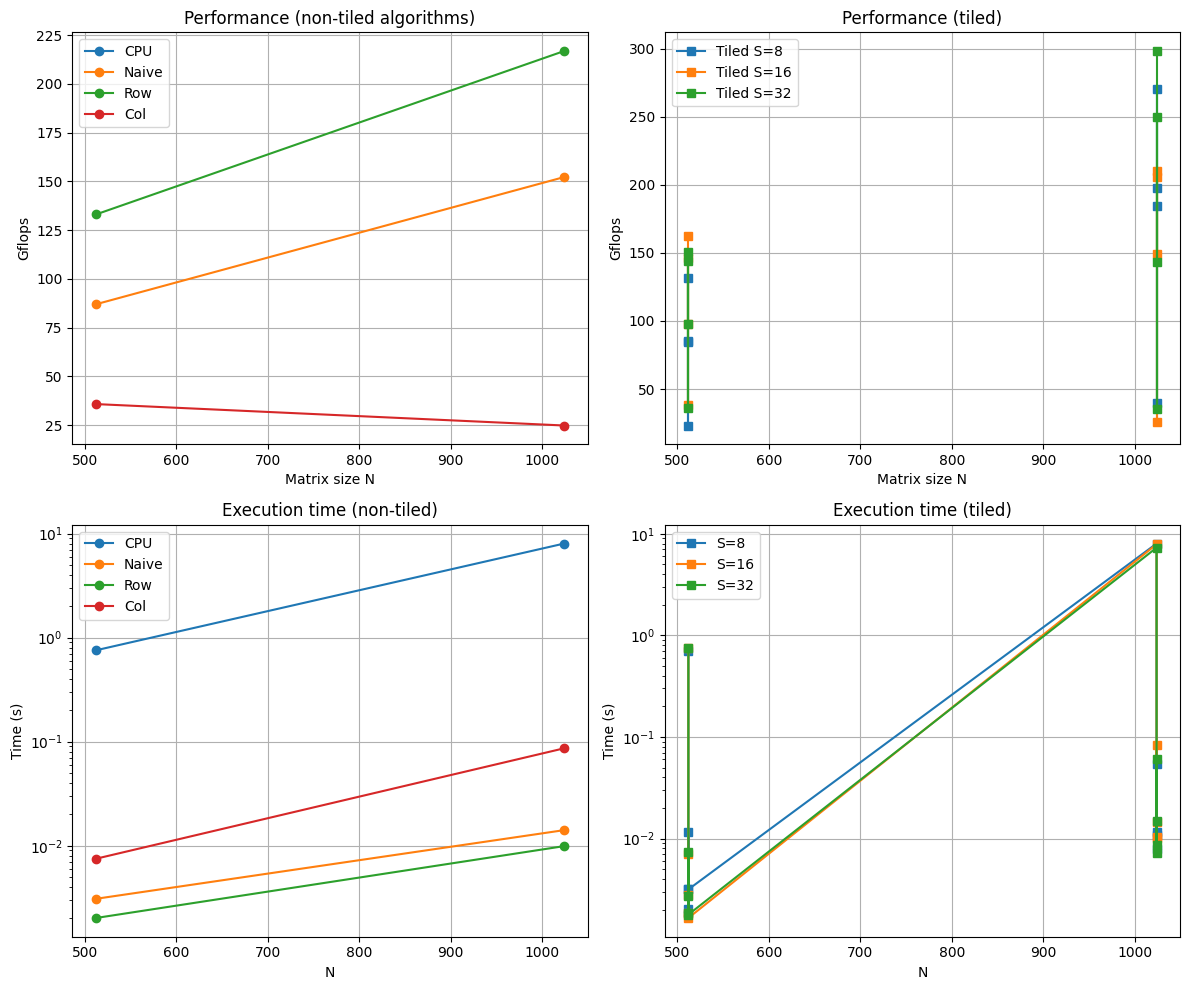

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Загрузим данные
df = pd.read_csv("results.csv")

# График 1: Производительность разных алгоритмов при S=16 (для всех N)
df_tiled_16 = df[(df["S"] == 16) | (df["S"] == 0)] # 0 для non-tiled
# Но для naive/cache S всегда 0 в данных. Разделим:
df_non_tiled = df[df["S"] == 0]
df_tiled = df[df["S"] > 0]

plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
# Группируем по алгоритму и N, берём среднее (если повторы)
for algo in df_non_tiled["algorithm"].unique():
    subset = df_non_tiled[df_non_tiled["algorithm"] == algo]
    plt.plot(subset["N"], subset["gflops"], marker='o', label=algo)
plt.xlabel("Matrix size N")
plt.ylabel("Gflops")
plt.title("Performance (non-tiled algorithms)")
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 2)
# Для tiled: покажем для каждого S по отдельности
for S in [8, 16, 32]:
    subset = df_tiled[df_tiled["S"] == S]
    plt.plot(subset["N"], subset["gflops"], marker='s', label=f"Tiled S={S}")
plt.xlabel("Matrix size N")
plt.ylabel("Gflops")
plt.title("Performance (tiled)")
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 3)
for algo in df_non_tiled["algorithm"].unique():
    subset = df_non_tiled[df_non_tiled["algorithm"] == algo]
    plt.plot(subset["N"], subset["time_sec"], marker='o', label=algo)
plt.xlabel("N")
plt.ylabel("Time (s)")
plt.title("Execution time (non-tiled)")
plt.yscale('log')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 4)
for S in [8, 16, 32]:
    subset = df_tiled[df_tiled["S"] == S]
    plt.plot(subset["N"], subset["time_sec"], marker='s', label=f"S={S}")
plt.xlabel("N")
plt.ylabel("Time (s)")
plt.yscale('log')
plt.title("Execution time (tiled)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("cuda_perf_plots.png", dpi=150)
plt.show()